This code is designed for data collect from Nikon JOBS, name the sample as "Rep_D6_087.nd2", have 3 channel, DAPI, GFP, Dsred in z stacks.

In [1]:
# =============================================================================
# Cell 1: Import Libraries and Check CUDA Availability
# =============================================================================
import os
import re
import gc
import torch
import numpy as np
import tifffile
import pandas as pd
from nd2reader import ND2Reader
from tqdm import tqdm
from cellpose import models

# Check if CUDA is available
cuda_available = torch.cuda.is_available()
print(f"CUDA Available: {cuda_available}")
if cuda_available:
    gpu_name = torch.cuda.get_device_name(0)
    print(f"GPU Name: {gpu_name}")
else:
    print("No GPU detected or CUDA is not available.")

CUDA Available: True
GPU Name: NVIDIA GeForce RTX 4090


In [2]:
# check the iamge file for example
import os
from nd2reader import ND2Reader

def check_nd2_info(nd2_path):
    """
    Opens an ND2 file and prints image information including:
      - Detected axes
      - Image dimensions (shape)
      - Channel names (if available)
      - Additional metadata
    """
    try:
        with ND2Reader(nd2_path) as img:
            print(f"\nProcessing ND2 File: {os.path.basename(nd2_path)}")
            print("Detected Axes:", img.axes)
            print("Image Shape:", img.shape)
            
            channels = img.metadata.get('channels')
            if channels:
                print("Channels:", channels)
            else:
                print("No channel information available in metadata.")
            
            # Print additional metadata keys and values
            print("Additional Metadata:")
            for key, value in img.metadata.items():
                print(f"  {key}: {value}")
    except Exception as e:
        print(f"Error processing {nd2_path}: {e}")

# Specify the ND2 file you want to inspect
nd2_file_path = r"A:\_Ongoing\20250307_ActRep\AR_A1_001.nd2"
check_nd2_info(nd2_file_path)



Processing ND2 File: AR_A1_001.nd2
Detected Axes: ['x', 'y', 'c', 't', 'z']
Image Shape: (7, 900, 600)
Channels: ['40x 405', '40x 561', '40x 488']
Additional Metadata:
  height: 900
  width: 600
  date: 2025-03-07 17:33:15
  fields_of_view: [0]
  frames: [0]
  z_levels: range(0, 7)
  z_coordinates: [4822.180000000001, 4822.780000000002, 4823.360000000001, 4823.980000000001, 4824.580000000002, 4825.180000000001, 4825.780000000002]
  total_images_per_channel: 7
  channels: ['40x 405', '40x 561', '40x 488']
  pixel_microns: 0.273400847258364
  num_frames: 1
  experiment: {'description': '', 'loops': []}
  events: []


In [3]:
# =============================================================================
# Configuration: Define Channel Names (Edit these if channel names change)
# =============================================================================
CHANNEL_DAPI  = '40x 405'   # Used for cell mask generation
CHANNEL_DsRed = '40x 561'
CHANNEL_GFP   = '40x 488'

In [4]:
# =============================================================================
# Function: Convert ND2 to TIFF for a Given Channel
# =============================================================================
def convert_nd2_to_tiff_channel(nd2_path, tiff_output_dir, channel_name):
    """
    Converts an ND2 file to TIFF files by performing a maximum intensity projection
    over the z-axis for the specified channel.
    
    Parameters:
      nd2_path: Path to the input ND2 file.
      tiff_output_dir: Directory where the TIFF files will be saved.
      channel_name: Name of the channel to extract.
    """
    try:
        with ND2Reader(nd2_path) as img:
            print(f"\nProcessing ND2 file: {os.path.basename(nd2_path)}")
            print("Detected Axes:", img.axes)
            print("Detected Shape:", img.shape)
            
            channels = img.metadata.get('channels')
            if channels is None:
                raise ValueError("No channel information found in ND2 metadata.")
            print("Channels in file:", channels)
            
            if channel_name in channels:
                channel_index = channels.index(channel_name)
                print(f"Using channel '{channel_name}' at index {channel_index}.")
            else:
                print(f"Channel '{channel_name}' not found in {nd2_path}. Skipping conversion for this channel.")
                return
            
            img.default_coords['c'] = channel_index

            # Setup iteration: if a time axis exists, iterate over it and bundle z,y,x.
            if 't' in img.axes and img.sizes.get('t', 1) > 1:
                img.iter_axes = 't'
                img.bundle_axes = 'zyx'
            else:
                img.iter_axes = ''
                img.bundle_axes = 'zyx'
                
            # For each time frame (or single image), perform a max projection along z.
            for idx, frame in enumerate(img):
                max_proj = np.max(frame, axis=0)
                base_name = os.path.splitext(os.path.basename(nd2_path))[0]
                if 't' in img.axes and img.sizes.get('t', 1) > 1:
                    tiff_filename = f"{base_name}_t{idx}.tiff"
                else:
                    tiff_filename = f"{base_name}.tiff"
                tiff_path = os.path.join(tiff_output_dir, tiff_filename)
                tifffile.imwrite(tiff_path, max_proj)
                print(f"Saved TIFF: {tiff_path}")
    except Exception as e:
        print(f"Error converting {nd2_path} for channel {channel_name} to TIFF: {e}")

# =============================================================================
# Function: Generate Cell Mask Using Cellpose (Using DAPI Channel)
# =============================================================================
def generate_cellmask(tiff_path, mask_path, model):
    """
    Generates a cell mask from the given TIFF image (typically DAPI) using Cellpose and saves the mask.
    
    Parameters:
      tiff_path: Path to the TIFF image used for mask generation.
      mask_path: Output path for the generated mask TIFF.
      model: An instance of the Cellpose model.
    """
    try:
        img = tifffile.imread(tiff_path)
        # If the image is 3D (a stack), average over the first axis to obtain a 2D image.
        if img.ndim == 3:
            img = img.mean(axis=0)
        elif img.ndim > 3:
            raise ValueError(f"Unexpected number of dimensions ({img.ndim}) in image: {tiff_path}")

        img_min, img_max = np.min(img), np.max(img)
        dynamic_range = img_max - img_min
        if dynamic_range == 0:
            print(f"Warning: Image {tiff_path} has zero dynamic range. Skipping mask generation.")
            return
        
        img = img.astype(np.float32)
        img = (img - img_min) / dynamic_range

        if not np.isfinite(img).all():
            print(f"Warning: Image {tiff_path} contains non-finite values after normalization. Skipping.")
            return

        # Run Cellpose (adjust parameters such as diameter if needed)
        masks, flows, styles, diams = model.eval(
            img,
            diameter=100,
            flow_threshold=0.4,
            cellprob_threshold=0.0,
            channels=[0, 0]
        )
        tifffile.imwrite(mask_path, masks.astype(np.uint16))
        print(f"Saved cell mask: {mask_path}")
    except Exception as e:
        print(f"Error generating mask for {tiff_path}: {e}")
    finally:
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

# =============================================================================
# Function: Calculate Cell-Level Intensities
# =============================================================================
def calculate_intensities(tiff_files, tiff_dirs, mask_dir, output_csv):
    """
    For each TIFF file, calculates the average intensity per cell (using the generated mask)
    for both GFP and DsRed channels and saves the data to a CSV file.
    
    Parameters:
      tiff_files: List of TIFF filenames (assumed to be identical for GFP and DsRed channels).
      tiff_dirs: Dictionary with keys "GFP" and "DsRed" mapping to their respective TIFF directories.
      mask_dir: Directory where the cell masks are stored.
      output_csv: Path for the output CSV file.
    """
    data = []
    for tiff_file in tqdm(tiff_files, desc="Calculating Intensities"):
        gfp_path = os.path.join(tiff_dirs["GFP"], tiff_file)
        dsred_path = os.path.join(tiff_dirs["DsRed"], tiff_file)
        mask_filename = os.path.splitext(tiff_file)[0] + "_mask.tiff"
        mask_path = os.path.join(mask_dir, mask_filename)
        
        if not os.path.exists(gfp_path):
            print(f"GFP image {gfp_path} not found. Skipping.")
            continue
        if not os.path.exists(dsred_path):
            print(f"DsRed image {dsred_path} not found. Skipping.")
            continue
        if not os.path.exists(mask_path):
            print(f"Mask image {mask_path} not found. Skipping.")
            continue
        
        gfp_img = tifffile.imread(gfp_path)
        dsred_img = tifffile.imread(dsred_path)
        mask_img = tifffile.imread(mask_path)
        
        mask_indices = np.unique(mask_img)
        mask_indices = mask_indices[mask_indices != 0]  # Exclude background
        
        for idx in mask_indices:
            cell_mask = (mask_img == idx)
            avg_gfp = np.mean(gfp_img[cell_mask])
            avg_dsred = np.mean(dsred_img[cell_mask])
            data.append({
                "File Name": tiff_file,
                "Mask Index": idx,
                "Average GFP Intensity": avg_gfp,
                "Average DsRed Intensity": avg_dsred
            })
    
    df = pd.DataFrame(data)
    df.to_csv(output_csv, index=False)
    print(f"Cell-level intensity data saved to {output_csv}")

# =============================================================================
# Helper Function: Extract Group, Sample, and Repeat Information
# =============================================================================
def extract_info_from_filename(filename):
    """
    Extracts group (Act/Rep), sample, and repeat information from the filename.
    It first removes any time suffix (e.g., _t0) if present.
    
    Expected filename formats include:
      - 'Act_01_002.nd2'
      - 'Rep_A1_001.nd2'
    """
    base = re.sub(r'_t\d+', '', os.path.splitext(filename)[0])
    pattern = re.compile(r'^(Act|Rep)_([A-Za-z0-9]+)_(\d{3})', re.IGNORECASE)
    m = pattern.search(base)
    if m:
        return m.group(1), m.group(2), m.group(3)
    else:
        return 'Unknown', 'Unknown', 'Unknown'

# =============================================================================
# Runnable Step 1: ND2-to-TIFF Conversion for Each Channel
# =============================================================================
def run_conversion(nd2_dir, dapi_tiff_dir, dsred_tiff_dir, gfp_tiff_dir):
    """
    Converts all ND2 files in the given directory into TIFF images for the DAPI, DsRed, and GFP channels.
    
    Parameters:
      nd2_dir: Directory containing ND2 files.
      dapi_tiff_dir: Output directory for the DAPI TIFF images.
      dsred_tiff_dir: Output directory for the DsRed TIFF images.
      gfp_tiff_dir: Output directory for the GFP TIFF images.
    """
    nd2_files = [f for f in os.listdir(nd2_dir) if f.lower().endswith('.nd2')]
    if not nd2_files:
        print("No ND2 files found in", nd2_dir)
        return
    print(f"Found {len(nd2_files)} ND2 file(s) for conversion.")
    for nd2_file in nd2_files:
        nd2_path = os.path.join(nd2_dir, nd2_file)
        print(f"\n--- Processing: {nd2_file} ---")
        # Convert DAPI channel (for cell mask generation)
        convert_nd2_to_tiff_channel(nd2_path, dapi_tiff_dir, CHANNEL_DAPI)
        # Convert DsRed and GFP channels (for intensity analysis)
        convert_nd2_to_tiff_channel(nd2_path, dsred_tiff_dir, CHANNEL_DsRed)
        convert_nd2_to_tiff_channel(nd2_path, gfp_tiff_dir, CHANNEL_GFP)

# code to analysis

In [5]:
# =============================================================================
# Set Up Directories and Run Conversion
# =============================================================================
nd2_dir       = r"A:\_Ongoing\20250307_ActRep"
output_dir    = os.path.join(nd2_dir, "Output")
dapi_tiff_dir = os.path.join(output_dir, "DAPI_TIFF")
dsred_tiff_dir= os.path.join(output_dir, "DsRed_TIFF")
gfp_tiff_dir  = os.path.join(output_dir, "GFP_TIFF")
mask_dir      = os.path.join(output_dir, "mask_100")

# Create output directories if they don't exist
os.makedirs(output_dir, exist_ok=True)
os.makedirs(dapi_tiff_dir, exist_ok=True)
os.makedirs(dsred_tiff_dir, exist_ok=True)
os.makedirs(gfp_tiff_dir, exist_ok=True)
os.makedirs(mask_dir, exist_ok=True)

# Run ND2-to-TIFF conversion
run_conversion(nd2_dir, dapi_tiff_dir, dsred_tiff_dir, gfp_tiff_dir)

Found 2400 ND2 file(s) for conversion.

--- Processing: AR_A1_001.nd2 ---

Processing ND2 file: AR_A1_001.nd2
Detected Axes: ['x', 'y', 'c', 't', 'z']
Detected Shape: (7, 900, 600)
Channels in file: ['40x 405', '40x 561', '40x 488']
Using channel '40x 405' at index 0.
Saved TIFF: A:\_Ongoing\20250307_ActRep\Output\DAPI_TIFF\AR_A1_001.tiff

Processing ND2 file: AR_A1_001.nd2
Detected Axes: ['x', 'y', 'c', 't', 'z']
Detected Shape: (7, 900, 600)
Channels in file: ['40x 405', '40x 561', '40x 488']
Using channel '40x 561' at index 1.
Saved TIFF: A:\_Ongoing\20250307_ActRep\Output\DsRed_TIFF\AR_A1_001.tiff

Processing ND2 file: AR_A1_001.nd2
Detected Axes: ['x', 'y', 'c', 't', 'z']
Detected Shape: (7, 900, 600)
Channels in file: ['40x 405', '40x 561', '40x 488']
Using channel '40x 488' at index 2.
Saved TIFF: A:\_Ongoing\20250307_ActRep\Output\GFP_TIFF\AR_A1_001.tiff

--- Processing: AR_A1_002.nd2 ---

Processing ND2 file: AR_A1_002.nd2
Detected Axes: ['x', 'y', 'c', 't', 'z']
Detected Shap

In [ ]:
# =============================================================================
# Runnable Step 2: Cell Mask Generation Using DAPI Channel
# =============================================================================
def run_mask_generation(dapi_tiff_dir, mask_dir, model):
    """
    Generates cell masks from DAPI channel TIFF images using Cellpose.
    
    Parameters:
      dapi_tiff_dir: Directory containing DAPI TIFF images (for cell mask generation).
      mask_dir: Directory where the generated mask images will be saved.
      model: An initialized Cellpose model.
    """
    # Filter out TIFF files that are not masks already
    dapi_tiff_files = [f for f in os.listdir(dapi_tiff_dir)
                       if f.lower().endswith(('.tiff', '.tif')) and '_mask' not in f]
    
    if not dapi_tiff_files:
        print("No DAPI TIFF files found in", dapi_tiff_dir)
        return
    
    print(f"Generating cell masks for {len(dapi_tiff_files)} DAPI TIFF file(s)...")
    for tiff_file in tqdm(dapi_tiff_files, desc="Generating Masks"):
        tiff_path = os.path.join(dapi_tiff_dir, tiff_file)
        mask_filename = os.path.splitext(tiff_file)[0] + "_mask.tiff"
        mask_path = os.path.join(mask_dir, mask_filename)
        generate_cellmask(tiff_path, mask_path, model)
    
    print("Cell mask generation completed.")

# =============================================================================
# Initialize the Cellpose Model and Run Mask Generation
# =============================================================================
print("\n=== Cell Mask Generation ===")
try:
    model = models.Cellpose(gpu=torch.cuda.is_available(), model_type="cyto3")
    print("Cellpose model initialized.")
except Exception as e:
    print("Error initializing Cellpose model:", e)
    print("Falling back to CPU mode with cyto2.")
    model = models.Cellpose(gpu=False, model_type="cyto2")

# Run mask generation using the DAPI channel TIFF images
run_mask_generation(dapi_tiff_dir, mask_dir, model)


In [ ]:
# filter out small mask
import os
import numpy as np
import tifffile
from tqdm import tqdm

# -----------------------------
# SET UP DIRECTORIES
# -----------------------------
nd2_dir = r"A:\_Ongoing\20250307_ActRep"
output_dir = os.path.join(nd2_dir, "Output")
mask_dir = os.path.join(output_dir, "mask_100")  # Original mask folder
new_mask_dir = os.path.join(output_dir, "mask_filtered")  # New folder for filtered masks
os.makedirs(new_mask_dir, exist_ok=True)

# -----------------------------
# FILTER PARAMETERS
# -----------------------------
size_threshold = 600  # Objects with area < 600 pixels will be removed

# -----------------------------
# PROCESS EACH MASK FILE
# -----------------------------
mask_files = [f for f in os.listdir(mask_dir) if f.lower().endswith(('.tif', '.tiff'))]

for mask_file in tqdm(mask_files, desc="Filtering masks"):
    mask_path = os.path.join(mask_dir, mask_file)
    new_mask_path = os.path.join(new_mask_dir, mask_file)
    try:
        # Read the mask image
        mask_img = tifffile.imread(mask_path)
        
        # Create a copy for filtering
        filtered_mask = mask_img.copy()
        
        # Get unique object labels (excluding background label 0)
        obj_ids = np.unique(mask_img)
        obj_ids = obj_ids[obj_ids != 0]
        
        # Loop over each object and remove if its area is below the threshold
        for obj in obj_ids:
            area = np.sum(mask_img == obj)
            if area < size_threshold:
                filtered_mask[mask_img == obj] = 0
        
        # Save the filtered mask to the new folder
        tifffile.imwrite(new_mask_path, filtered_mask.astype(np.uint16))
        print(f"Saved filtered mask: {new_mask_path}")
        
    except Exception as e:
        print(f"Error processing {mask_file}: {e}")


# cellpose checing visulize

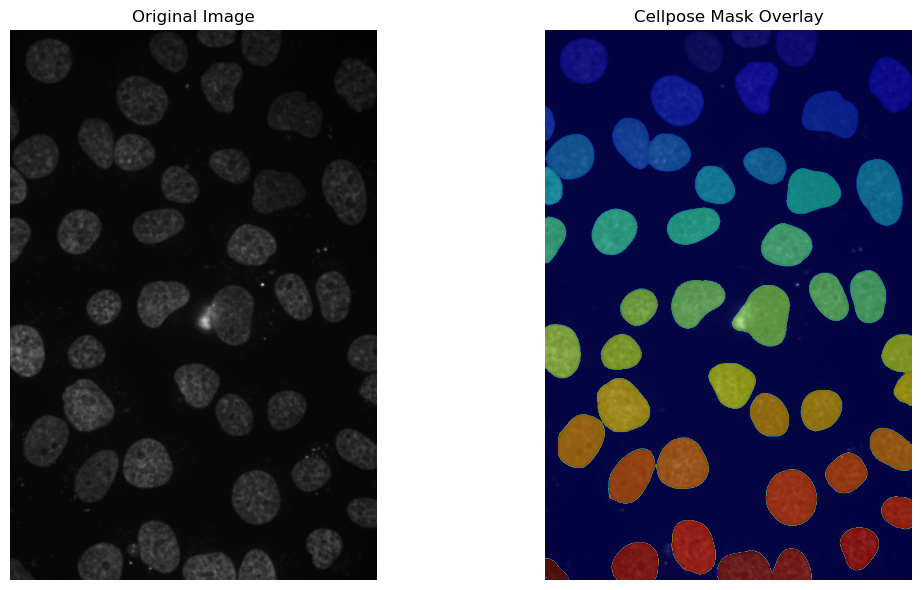

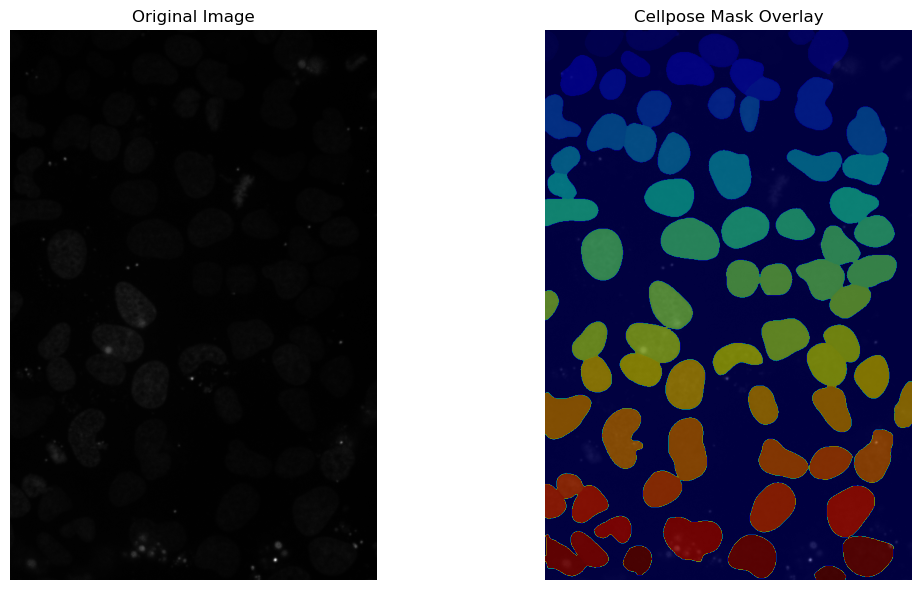

In [4]:
import random
import os
import tifffile
import matplotlib.pyplot as plt
import numpy as np

def visualize_random_samples(image_dir, mask_dir, num_samples=5, seed=None):
    """
    Randomly selects and visualizes TIFF images with their corresponding Cellpose masks.
    
    Parameters:
      image_dir (str): Directory containing the original TIFF images (e.g., DAPI images used for mask generation).
      mask_dir (str): Directory containing the Cellpose mask TIFFs.
      num_samples (int): Number of random samples to visualize.
      seed (int, optional): Seed for reproducibility.
    """
    # Set seed for reproducibility if provided
    if seed is not None:
        random.seed(seed)
    
    # Get list of TIFF files (exclude mask files)
    image_files = [f for f in os.listdir(image_dir) 
                   if f.lower().endswith(('.tiff', '.tif')) and '_mask' not in f]
    
    if not image_files:
        print(f"No TIFF files found in {image_dir}.")
        return
    
    # Adjust number of samples if there are fewer files than requested
    num_samples = min(num_samples, len(image_files))
    samples = random.sample(image_files, num_samples)
    
    for img_file in samples:
        img_path = os.path.join(image_dir, img_file)
        mask_filename = os.path.splitext(img_file)[0] + "_mask.tiff"
        mask_path = os.path.join(mask_dir, mask_filename)
        
        # Check if the corresponding mask file exists
        if not os.path.exists(mask_path):
            print(f"Mask file {mask_filename} does not exist. Skipping {img_file}.")
            continue
        
        try:
            img = tifffile.imread(img_path)
            mask = tifffile.imread(mask_path)
            
            # If the image has multiple channels, average them to get a grayscale representation
            if img.ndim == 3:
                img_display = img.mean(axis=0)
            else:
                img_display = img
            
            # Normalize the image for display purposes
            img_display = img_display.astype(np.float32)
            img_display -= img_display.min()
            if img_display.max() != 0:
                img_display /= img_display.max()
            
            plt.figure(figsize=(12, 6))
            
            # Display the original image
            plt.subplot(1, 2, 1)
            plt.imshow(img_display, cmap='gray')
            plt.title('Original Image')
            plt.axis('off')
            
            # Display the mask overlay on the original image
            plt.subplot(1, 2, 2)
            plt.imshow(img_display, cmap='gray')
            plt.imshow(mask, cmap='jet', alpha=0.5)  # Overlay mask with transparency
            plt.title('Cellpose Mask Overlay')
            plt.axis('off')
            
            plt.tight_layout()
            plt.show()
            
        except Exception as e:
            print(f"Error visualizing {img_file}: {e}")

# =============================================================================
# Example Usage
# =============================================================================
# Define the directories for DAPI images (used for mask generation) and the generated masks.
dapi_image_dir = r"A:\_Ongoing\20250307_ActRep\Output\DAPI_TIFF"
mask_output_dir = r"A:\_Ongoing\20250307_ActRep\Output\mask_filtered"

# Visualize random samples (e.g., 2 samples, with a seed for reproducibility)
visualize_random_samples(dapi_image_dir, mask_output_dir, num_samples=2, seed=423133)


# Summary the data from mask, GFP and DeRed

In [5]:
import os
import numpy as np
import pandas as pd
import tifffile
from tqdm import tqdm

# =============================================================================
# New Extraction Function for the Updated Naming Strategy
# =============================================================================
def extract_info_from_filename_new(filename):
    """
    Extracts group, sample, and repeat information from a filename with naming strategy:
    "AR_{sample_code}_{repeat}.ext"
    where sample_code is one of A1, A2, A3, A4, B1, B2, B3, B4, C1, C2, C3, C4.
    
    The group is determined from the sample code:
      - If the last character of sample_code is '1' or '2', group = "Act"
      - If it is '3' or '4', group = "Rep"
      
    Returns:
      A tuple: (Group, Sample, Repeat)
    """
    # Remove the extension and the "AR_" prefix if present
    base = os.path.splitext(filename)[0]
    if base.startswith("AR_"):
        base = base[3:]
    # Expecting a format like "A1_001"
    parts = base.split("_")
    if len(parts) != 2:
        return "Unknown", "Unknown", "Unknown"
    sample_code = parts[0]
    repeat = parts[1]
    # Determine group based on the last character of the sample code.
    if sample_code[-1] in ['1', '2']:
        group = "Act"
    elif sample_code[-1] in ['3', '4']:
        group = "Rep"
    else:
        group = "Unknown"
    return group, sample_code, repeat

# =============================================================================
# Sample Mapping Dictionary (New Naming Strategy)
# =============================================================================
sample_mapping = {
    "A1": "Act VP16",
    "A2": "Act RUNX2CTD",
    "A3": "Rep VP16",
    "A4": "Rep RUNX2CTD",
    "B1": "Act LAP*",
    "B2": "Act LIP",
    "B3": "Rep LAP*",
    "B4": "Rep LIP",
    "C1": "Act Halo",
    "C2": "Act blank",
    "C3": "Rep Halo",
    "C4": "Rep blank"
}

# =============================================================================
# Function: Create Excel Summary from TIFF and Mask Data
# =============================================================================
def create_excel_from_tiff_and_mask_new(dsred_tiff_dir, gfp_tiff_dir, mask_dir, output_excel):
    """
    Processes DSred TIFF files (with corresponding GFP and mask files) to calculate cell-level intensities.
    For each cell (as determined by the mask), computes the average intensities in the GFP and DsRed channels.
    
    The file name is assumed to follow the pattern "AR_{sample_code}_{repeat}.ext". 
    Group, Sample, and Repeat are extracted using the new naming strategy.
    A descriptive sample name is added via the sample_mapping dictionary.
    
    The summary is saved as an Excel file.
    """
    # List DSred TIFF files (exclude any files with "_mask" in the name)
    dsred_files = [f for f in os.listdir(dsred_tiff_dir)
                   if f.lower().endswith(('.tif', '.tiff')) and "_mask" not in f]
    
    if not dsred_files:
        print("No DSred TIFF files found in", dsred_tiff_dir)
        return
    
    data = []
    for tiff_file in tqdm(dsred_files, desc="Processing TIFF files"):
        dsred_path = os.path.join(dsred_tiff_dir, tiff_file)
        gfp_path = os.path.join(gfp_tiff_dir, tiff_file)
        mask_filename = os.path.splitext(tiff_file)[0] + "_mask.tiff"
        mask_path = os.path.join(mask_dir, mask_filename)
        
        # Verify that the corresponding GFP and mask files exist.
        if not os.path.exists(gfp_path):
            print(f"GFP file not found for {tiff_file}, skipping.")
            continue
        if not os.path.exists(mask_path):
            print(f"Mask file not found for {tiff_file}, skipping.")
            continue
        
        try:
            dsred_img = tifffile.imread(dsred_path)
            gfp_img = tifffile.imread(gfp_path)
            mask_img = tifffile.imread(mask_path)
        except Exception as e:
            print(f"Error reading files for {tiff_file}: {e}")
            continue
        
        # Identify unique cell labels (ignore background 0)
        cell_indices = np.unique(mask_img)
        cell_indices = cell_indices[cell_indices != 0]
        
        # Compute average intensities for each cell
        for cell in cell_indices:
            cell_mask = (mask_img == cell)
            avg_gfp = np.mean(gfp_img[cell_mask])
            avg_dsred = np.mean(dsred_img[cell_mask])
            record = {
                "File Name": tiff_file,
                "Mask Index": cell,
                "GFP_Mean": avg_gfp,
                "DsRed_Mean": avg_dsred
            }
            data.append(record)
    
    # Create DataFrame from the collected records.
    df = pd.DataFrame(data)
    
    # Extract metadata (Group, Sample, Repeat) from the file name using the new extraction function.
    df[['Group', 'Sample', 'Repeat']] = df['File Name'].apply(lambda x: pd.Series(extract_info_from_filename_new(x)))
    
    # Map sample codes to descriptive sample names.
    df["Sample_name"] = df["Sample"].map(sample_mapping)
    
    # Rearrange columns.
    df = df[['Group', 'Sample', 'Sample_name', 'Repeat', 'Mask Index', 'GFP_Mean', 'DsRed_Mean']]
    
    # Save the summary to an Excel file.
    df.to_excel(output_excel, index=False)
    print("Excel summary saved to:", output_excel)

# =============================================================================
# Example Usage
# =============================================================================
# Adjust these paths as needed for your data.
dsred_tiff_dir = r"A:\_Ongoing\20250307_ActRep\Output\DsRed_TIFF"
gfp_tiff_dir   = r"A:\_Ongoing\20250307_ActRep\Output\GFP_TIFF"
mask_dir       = r"A:\_Ongoing\20250307_ActRep\Output\mask_filtered"
output_excel   = r"A:\_Ongoing\20250307_ActRep\Output\summary_renamed.xlsx"

create_excel_from_tiff_and_mask_new(dsred_tiff_dir, gfp_tiff_dir, mask_dir, output_excel)


Processing TIFF files: 100%|██████████| 2400/2400 [01:17<00:00, 31.09it/s]


Excel summary saved to: A:\_Ongoing\20250307_ActRep\Output\summary_renamed.xlsx


# Plot Histgram

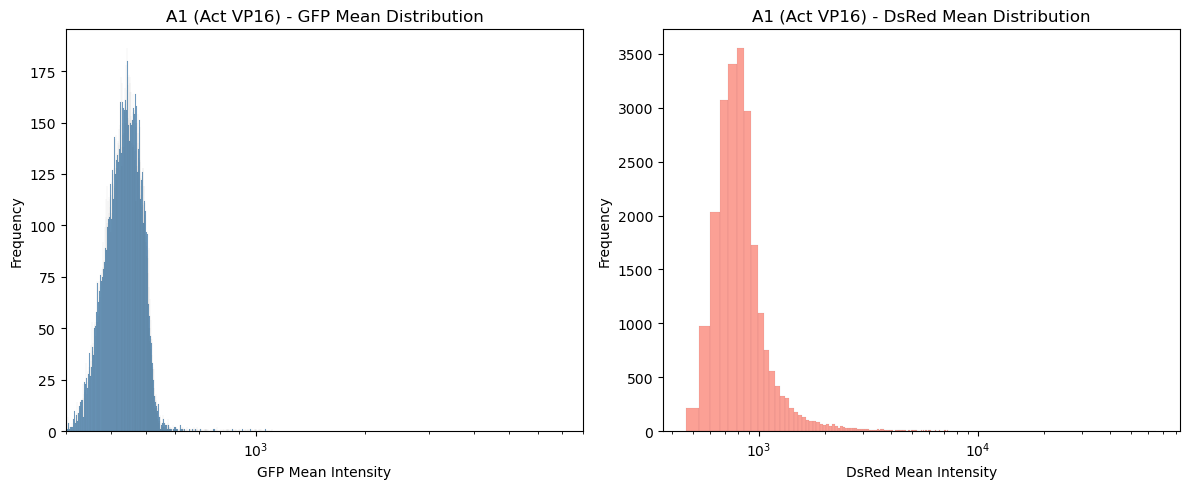

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_histograms_for_sample(df, sample_code):
    """
    Plots histograms (with KDE overlay) of GFP_Mean and DsRed_Mean for a given sample,
    with the x-axis set to a log scale.
    
    Parameters:
      df (DataFrame): The DataFrame containing the summary data.
      sample_code (str): The sample code (e.g., "A1", "B3") to filter by.
    """
    # Filter rows for the given sample code.
    df_sample = df[df["Sample"] == sample_code]
    if df_sample.empty:
        print(f"No data found for sample {sample_code}.")
        return
    # Retrieve the descriptive sample name if available.
    sample_name = df_sample["Sample_name"].iloc[0] if "Sample_name" in df_sample.columns else sample_code
    
    # Create a figure with two subplots: one for GFP_Mean and one for DsRed_Mean.
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Plot GFP_Mean histogram.
    sns.histplot(df_sample["GFP_Mean"], bins=1000, kde=False, ax=axes[0], color="steelblue")
    axes[0].set_title(f"{sample_code} ({sample_name}) - GFP Mean Distribution")
    axes[0].set_xlabel("GFP Mean Intensity")
    axes[0].set_ylabel("Frequency")
    axes[0].set_xscale("log")  # Set x-axis to log scale
    axes[0].set_xlim(300, 8000)
    
    # Plot DsRed_Mean histogram.
    sns.histplot(df_sample["DsRed_Mean"], bins=1000, kde=False, ax=axes[1], color="salmon")
    axes[1].set_title(f"{sample_code} ({sample_name}) - DsRed Mean Distribution")
    axes[1].set_xlabel("DsRed Mean Intensity")
    axes[1].set_ylabel("Frequency")
    axes[1].set_xscale("log")  # Set x-axis to log scale
    axes[0].set_xlim(300, 8000)
    
    plt.tight_layout()
    plt.show()

# -----------------------------
# Example: Plot Data for Sample A1
# -----------------------------
input_excel = r"A:\_Ongoing\20250307_ActRep\Output\summary_renamed.xlsx"
df = pd.read_excel(input_excel)
plot_histograms_for_sample(df, "A1")


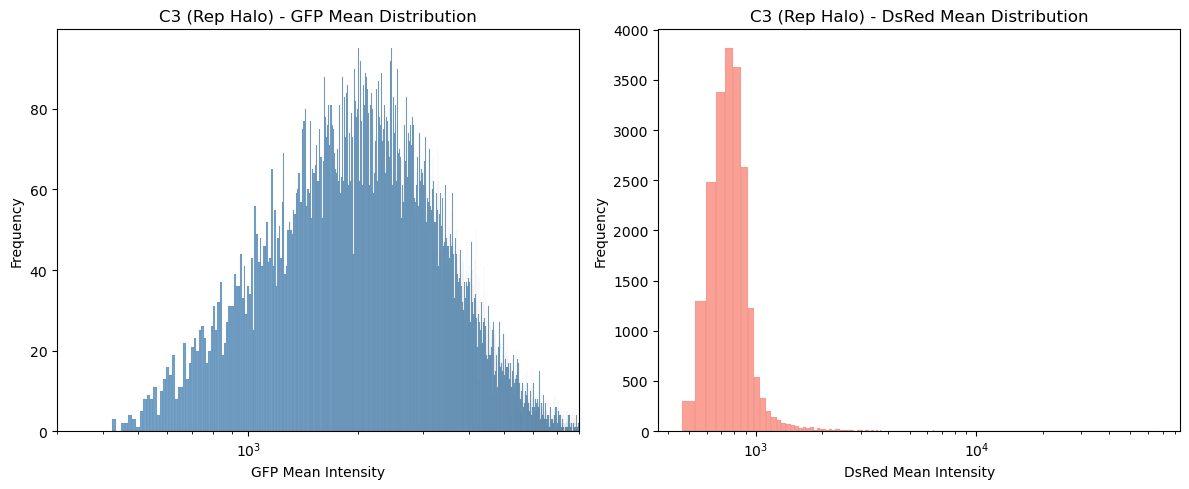

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_histograms_for_sample(df, sample_code):
    """
    Plots histograms (with KDE overlay) of GFP_Mean and DsRed_Mean for a given sample,
    with the x-axis set to a log scale.
    
    Parameters:
      df (DataFrame): The DataFrame containing the summary data.
      sample_code (str): The sample code (e.g., "A1", "B3") to filter by.
    """
    # Filter rows for the given sample code.
    df_sample = df[df["Sample"] == sample_code]
    if df_sample.empty:
        print(f"No data found for sample {sample_code}.")
        return
    # Retrieve the descriptive sample name if available.
    sample_name = df_sample["Sample_name"].iloc[0] if "Sample_name" in df_sample.columns else sample_code
    
    # Create a figure with two subplots: one for GFP_Mean and one for DsRed_Mean.
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Plot GFP_Mean histogram.
    sns.histplot(df_sample["GFP_Mean"], bins=1000, kde=False, ax=axes[0], color="steelblue")
    axes[0].set_title(f"{sample_code} ({sample_name}) - GFP Mean Distribution")
    axes[0].set_xlabel("GFP Mean Intensity")
    axes[0].set_ylabel("Frequency")
    axes[0].set_xscale("log")  # Set x-axis to log scale
    axes[0].set_xlim(300, 8000)
    
    # Plot DsRed_Mean histogram.
    sns.histplot(df_sample["DsRed_Mean"], bins=1000, kde=False, ax=axes[1], color="salmon")
    axes[1].set_title(f"{sample_code} ({sample_name}) - DsRed Mean Distribution")
    axes[1].set_xlabel("DsRed Mean Intensity")
    axes[1].set_ylabel("Frequency")
    axes[1].set_xscale("log")  # Set x-axis to log scale
    axes[0].set_xlim(300, 8000)
    
    plt.tight_layout()
    plt.show()

# -----------------------------
# Example: Plot Data for Sample A1
# -----------------------------
input_excel = r"A:\_Ongoing\20250307_ActRep\Output\summary_renamed.xlsx"
df = pd.read_excel(input_excel)
plot_histograms_for_sample(df, "C3")

# compare two group at he same his plot

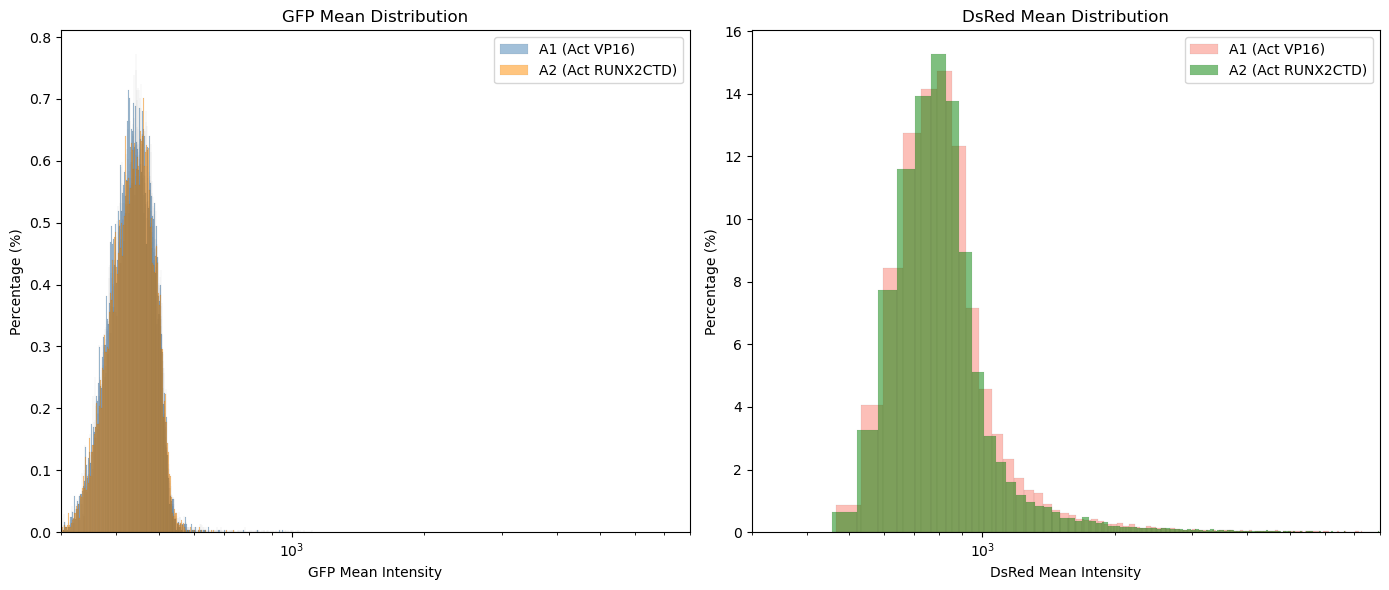

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_histograms_for_two_samples_percent(df, sample_code1, sample_code2, x_min, x_max):
    """
    Overlays histograms for GFP_Mean and DsRed_Mean for two given sample codes,
    with the y-axis showing the percentage of the total population (stat='percent'),
    so that samples with different numbers of data points can be compared.
    
    The x-axis is set to a log scale, with manual limits provided by x_min and x_max.
    """
    # Filter the data for each sample.
    df1 = df[df["Sample"] == sample_code1]
    df2 = df[df["Sample"] == sample_code2]
    
    if df1.empty:
        print(f"No data found for sample {sample_code1}.")
        return
    if df2.empty:
        print(f"No data found for sample {sample_code2}.")
        return
    
    # Retrieve descriptive sample names (if available)
    sample_name1 = df1["Sample_name"].iloc[0] if "Sample_name" in df1.columns else sample_code1
    sample_name2 = df2["Sample_name"].iloc[0] if "Sample_name" in df2.columns else sample_code2
    
    # Create a figure with two subplots: one for GFP_Mean and one for DsRed_Mean.
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Plot for GFP_Mean with y-axis in percentage.
    sns.histplot(
        df1["GFP_Mean"], bins=1000, kde=False, color="steelblue", alpha=0.5, 
        ax=axes[0], label=f"{sample_code1} ({sample_name1})", stat="percent"
    )
    sns.histplot(
        df2["GFP_Mean"], bins=1000, kde=False, color="darkorange", alpha=0.5, 
        ax=axes[0], label=f"{sample_code2} ({sample_name2})", stat="percent"
    )
    axes[0].set_title("GFP Mean Distribution")
    axes[0].set_xlabel("GFP Mean Intensity")
    axes[0].set_ylabel("Percentage (%)")
    axes[0].set_xscale("log")
    axes[0].set_xlim(x_min, x_max)
    axes[0].legend()
    
    # Plot for DsRed_Mean with y-axis in percentage.
    sns.histplot(
        df1["DsRed_Mean"], bins=1000, kde=False, color="salmon", alpha=0.5, 
        ax=axes[1], label=f"{sample_code1} ({sample_name1})", stat="percent"
    )
    sns.histplot(
        df2["DsRed_Mean"], bins=1000, kde=False, color="green", alpha=0.5, 
        ax=axes[1], label=f"{sample_code2} ({sample_name2})", stat="percent"
    )
    axes[1].set_title("DsRed Mean Distribution")
    axes[1].set_xlabel("DsRed Mean Intensity")
    axes[1].set_ylabel("Percentage (%)")
    axes[1].set_xscale("log")
    axes[1].set_xlim(x_min, x_max)
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

# -----------------------------
# Example Usage:
# -----------------------------
# Load the summary Excel file.
input_excel = r"A:\_Ongoing\20250307_ActRep\Output\summary_renamed.xlsx"
df = pd.read_excel(input_excel)

# Compare two samples (for example, "A1" vs "A2") with x-axis limits set from 300 to 8000.
plot_histograms_for_two_samples_percent(df, "A1", "A2", x_min=300, x_max=8000)



# base on Blank sample, filter out untransfected cell

In [34]:
import os
import numpy as np
import pandas as pd

# -----------------------------
# PARAMETERS & FILE PATHS
# -----------------------------
input_excel = r"A:\_Ongoing\20250307_ActRep\Output\summary_renamed.xlsx"  # Summary file with all cells
output_excel = r"A:\_Ongoing\20250307_ActRep\Output\summary_filtered_blank.xlsx"  # New output file

# Define blank sample codes for each group.
act_blank_code = "C2"  # Act blank sample code
rep_blank_code = "C4"  # Rep blank sample code

# -----------------------------
# READ DATA
# -----------------------------
df = pd.read_excel(input_excel)

# -----------------------------
# Compute 99th Percentile Thresholds for Each Group Based on Blank Data
# -----------------------------
# For Act group:
df_act = df[df["Group"] == "Act"]
df_act_blank = df_act[df_act["Sample"] == act_blank_code]
if df_act_blank.empty:
    print("No Act blank data found (sample code C2).")
    threshold_act = np.nan
else:
    threshold_act = np.percentile(df_act_blank["DsRed_Mean"].dropna(), 99.5)
    print(f"Act group: 99th percentile of DsRed_Mean in Act blank (sample {act_blank_code}) = {threshold_act}")

# For Rep group:
df_rep = df[df["Group"] == "Rep"]
df_rep_blank = df_rep[df_rep["Sample"] == rep_blank_code]
if df_rep_blank.empty:
    print("No Rep blank data found (sample code C4).")
    threshold_rep = np.nan
else:
    threshold_rep = np.percentile(df_rep_blank["DsRed_Mean"].dropna(), 99.5)
    print(f"Rep group: 99th percentile of DsRed_Mean in Rep blank (sample {rep_blank_code}) = {threshold_rep}")

# -----------------------------
# Filter Out Cells Below the Threshold for Each Group
# -----------------------------
if not np.isnan(threshold_act):
    df_act_filtered = df_act[df_act["DsRed_Mean"] >= threshold_act]
else:
    df_act_filtered = df_act.copy()

if not np.isnan(threshold_rep):
    df_rep_filtered = df_rep[df_rep["DsRed_Mean"] >= threshold_rep]
else:
    df_rep_filtered = df_rep.copy()

# Combine filtered data from both groups.
df_filtered = pd.concat([df_act_filtered, df_rep_filtered], ignore_index=True)

# Print summary statistics.
print("\nAct group: Total cells =", df_act.shape[0], 
      ", Passed =", df_act_filtered.shape[0], 
      ", Filtered out =", df_act.shape[0] - df_act_filtered.shape[0])
print("Rep group: Total cells =", df_rep.shape[0], 
      ", Passed =", df_rep_filtered.shape[0], 
      ", Filtered out =", df_rep.shape[0] - df_rep_filtered.shape[0])

# -----------------------------
# SAVE THE NEW SUMMARY TO EXCEL
# -----------------------------
df_filtered.to_excel(output_excel, index=False)
print("\nNew summary filtered by blank thresholds saved to:", output_excel)


Act group: 99th percentile of DsRed_Mean in Act blank (sample C2) = 1077.959346385207
Rep group: 99th percentile of DsRed_Mean in Rep blank (sample C4) = 1085.4908118826704

Act group: Total cells = 124259 , Passed = 17994 , Filtered out = 106265
Rep group: Total cells = 127378 , Passed = 6164 , Filtered out = 121214

New summary filtered by blank thresholds saved to: A:\_Ongoing\20250307_ActRep\Output\summary_filtered_blank.xlsx


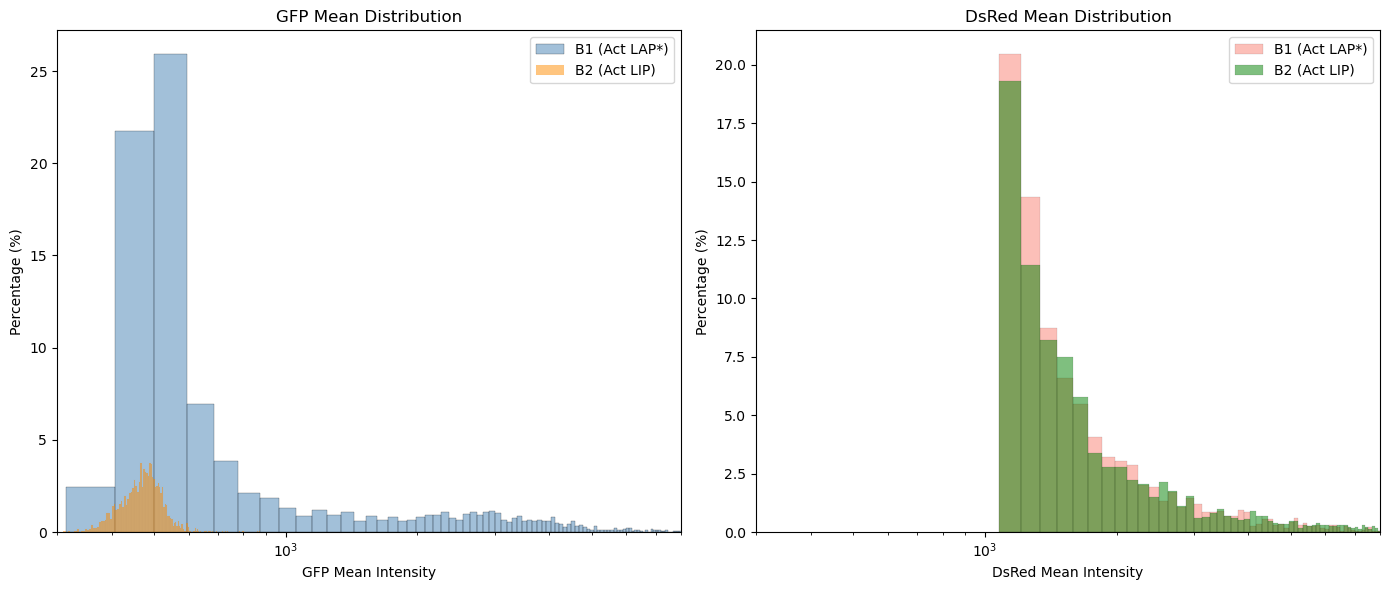

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_histograms_for_two_samples_percent(df, sample_code1, sample_code2, x_min, x_max):
    """
    Overlays histograms for GFP_Mean and DsRed_Mean for two given sample codes,
    with the y-axis showing the percentage of the total population (stat='percent'),
    so that samples with different numbers of data points can be compared.
    
    The x-axis is set to a log scale, with manual limits provided by x_min and x_max.
    """
    # Filter the data for each sample.
    df1 = df[df["Sample"] == sample_code1]
    df2 = df[df["Sample"] == sample_code2]
    
    if df1.empty:
        print(f"No data found for sample {sample_code1}.")
        return
    if df2.empty:
        print(f"No data found for sample {sample_code2}.")
        return
    
    # Retrieve descriptive sample names (if available)
    sample_name1 = df1["Sample_name"].iloc[0] if "Sample_name" in df1.columns else sample_code1
    sample_name2 = df2["Sample_name"].iloc[0] if "Sample_name" in df2.columns else sample_code2
    
    # Create a figure with two subplots: one for GFP_Mean and one for DsRed_Mean.
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Plot for GFP_Mean with y-axis in percentage.
    sns.histplot(
        df1["GFP_Mean"], bins=200, kde=False, color="steelblue", alpha=0.5, 
        ax=axes[0], label=f"{sample_code1} ({sample_name1})", stat="percent"
    )
    sns.histplot(
        df2["GFP_Mean"], bins=200, kde=False, color="darkorange", alpha=0.5, 
        ax=axes[0], label=f"{sample_code2} ({sample_name2})", stat="percent"
    )
    axes[0].set_title("GFP Mean Distribution")
    axes[0].set_xlabel("GFP Mean Intensity")
    axes[0].set_ylabel("Percentage (%)")
    axes[0].set_xscale("log")
    axes[0].set_xlim(x_min, x_max)
    axes[0].legend()
    
    # Plot for DsRed_Mean with y-axis in percentage.
    sns.histplot(
        df1["DsRed_Mean"], bins=500, kde=False, color="salmon", alpha=0.5, 
        ax=axes[1], label=f"{sample_code1} ({sample_name1})", stat="percent"
    )
    sns.histplot(
        df2["DsRed_Mean"], bins=500, kde=False, color="green", alpha=0.5, 
        ax=axes[1], label=f"{sample_code2} ({sample_name2})", stat="percent"
    )
    axes[1].set_title("DsRed Mean Distribution")
    axes[1].set_xlabel("DsRed Mean Intensity")
    axes[1].set_ylabel("Percentage (%)")
    axes[1].set_xscale("log")
    axes[1].set_xlim(x_min, x_max)
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

# -----------------------------
# Example Usage:
# -----------------------------
# Load the summary Excel file.
input_excel = r"A:\_Ongoing\20250307_ActRep\Output\summary_filtered_blank.xlsx"
df = pd.read_excel(input_excel)

# Compare two samples (for example, "A1" vs "A2") with x-axis limits set from 300 to 8000.
plot_histograms_for_two_samples_percent(df, "B1", "B2", x_min=300, x_max=8000)

# plot Histogram plot to check the GFP intensity for each cells before move on to filter out cells

# filter out the false negative cells with less than "cutoff_value" net DsRed value

# updated filter, keep the high absolute GFP_net_mean data

# Check the sample quality by find out which sample passed

# for two cutoff

# Plot the intensity

great, now I want to plot the data from our lastest excel. Act and Rep have their own plot.
 Creates a horizontal violin plot, The y-axis will display the sample names (descriptive names from the 'Sample_name' column)  in reversed order (i.e. the lowest sample code at the top). X-axis will be the GFP net mean intensity.

# after two cutoff plot:

# analyze the ratio of expression

# Plot